In [5]:
import pandas as pd

# Reading Excel file instead of CSV
df = pd.read_excel('E Commerce.xlsx')

print(df.shape)
print(df.head())

(10999, 12)
   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0                44           1233

In [6]:
# Check for missing values and data types
print("Missing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nBasic Stats:")
print(df.describe())

Missing Values:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

Data Types:
ID                      int64
Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object

Basic Stats:
                ID  Customer_care_calls  Customer_rating  Cost_of_the_Product  \
count  10999.00000         10999.000000     10999.000000         10999.000000   
mean    5500.00000             4.054459         2.990545           210.196836   
std     3175.28214         

In [7]:
# Rename confusing column to make it clear
df = df.rename(columns={'Reached.on.Time_Y.N': 'Late_delivery'})

# Add a readable label column
df['Delivery_status'] = df['Late_delivery'].map({1: 'Late', 0: 'On Time'})

print("✅ Data cleaned!")
print(df[['Late_delivery', 'Delivery_status']].head())

✅ Data cleaned!
   Late_delivery Delivery_status
0              1            Late
1              1            Late
2              1            Late
3              1            Late
4              1            Late


In [8]:
# 1. Overall late delivery rate
late_rate = df['Late_delivery'].mean() * 100
print(f"Overall Late Delivery Rate: {late_rate:.1f}%")

# 2. Late deliveries by shipping mode
print("\nLate Deliveries by Shipping Mode:")
print(df.groupby('Mode_of_Shipment')['Late_delivery'].mean().mul(100).round(1))

# 3. Late deliveries by warehouse
print("\nLate Deliveries by Warehouse:")
print(df.groupby('Warehouse_block')['Late_delivery'].mean().mul(100).round(1))

# 4. Average customer rating by delivery status
print("\nAvg Customer Rating (Late vs On Time):")
print(df.groupby('Delivery_status')['Customer_rating'].mean().round(2))


Overall Late Delivery Rate: 59.7%

Late Deliveries by Shipping Mode:
Mode_of_Shipment
Flight    60.2
Road      58.8
Ship      59.8
Name: Late_delivery, dtype: float64

Late Deliveries by Warehouse:
Warehouse_block
A    58.6
B    60.2
C    59.7
D    59.8
F    59.8
Name: Late_delivery, dtype: float64

Avg Customer Rating (Late vs On Time):
Delivery_status
Late       3.01
On Time    2.97
Name: Customer_rating, dtype: float64


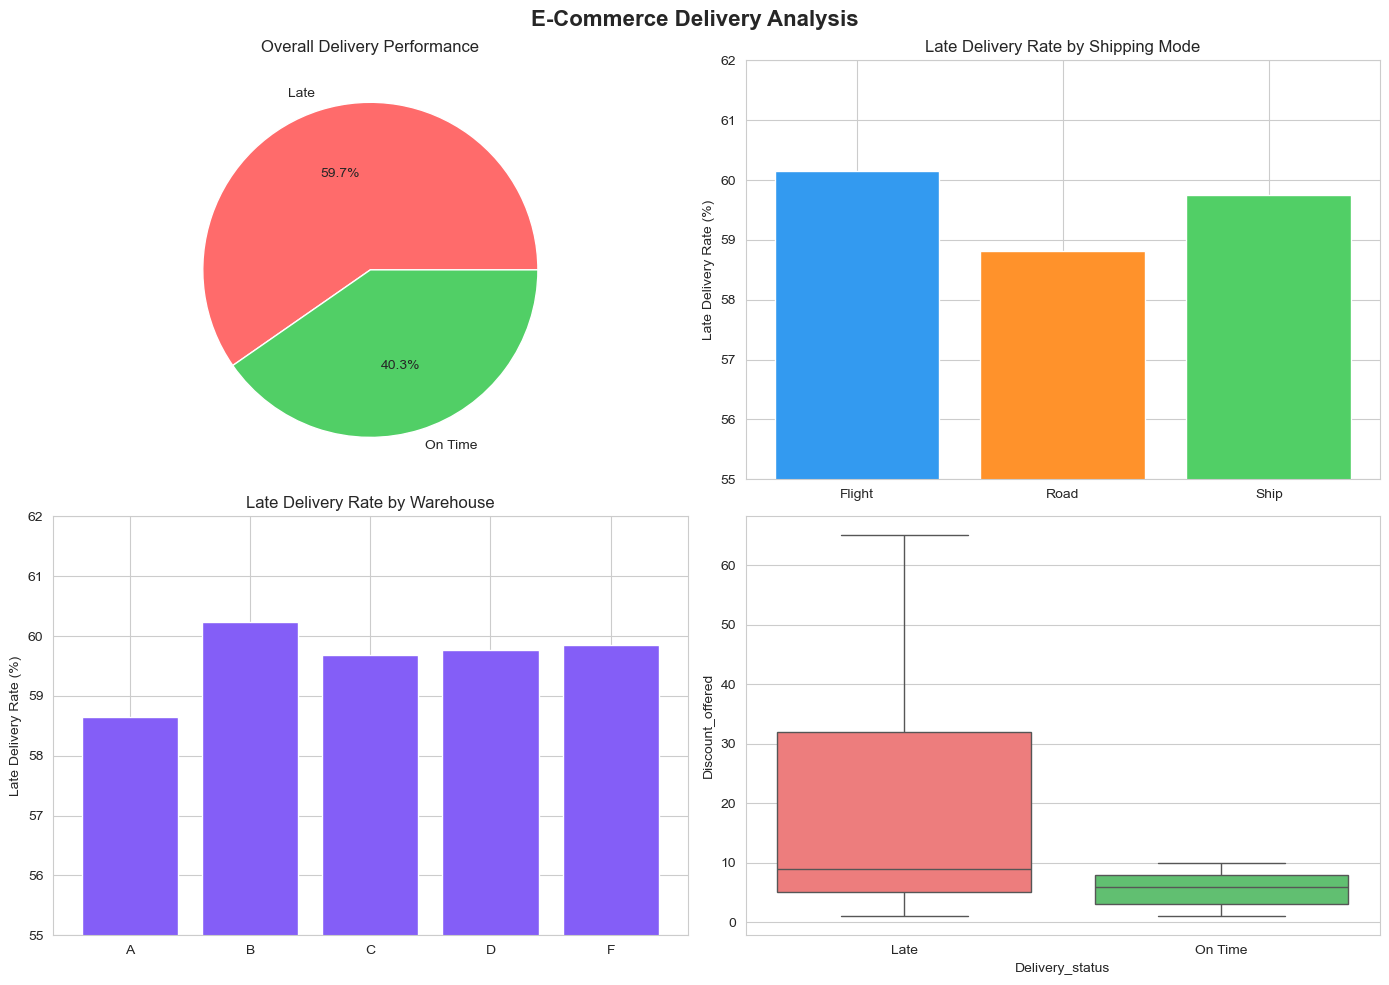

✅ Chart saved as delivery_analysis.png!


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('E-Commerce Delivery Analysis', fontsize=16, fontweight='bold')

# Chart 1 - Late vs On Time
delivery_counts = df['Delivery_status'].value_counts()
axes[0,0].pie(delivery_counts, labels=delivery_counts.index, 
              autopct='%1.1f%%', colors=['#ff6b6b','#51cf66'])
axes[0,0].set_title('Overall Delivery Performance')

# Chart 2 - By Shipping Mode
mode_data = df.groupby('Mode_of_Shipment')['Late_delivery'].mean().mul(100)
axes[0,1].bar(mode_data.index, mode_data.values, color=['#339af0','#ff922b','#51cf66'])
axes[0,1].set_title('Late Delivery Rate by Shipping Mode')
axes[0,1].set_ylabel('Late Delivery Rate (%)')
axes[0,1].set_ylim(55, 62)

# Chart 3 - By Warehouse
warehouse_data = df.groupby('Warehouse_block')['Late_delivery'].mean().mul(100)
axes[1,0].bar(warehouse_data.index, warehouse_data.values, color='#845ef7')
axes[1,0].set_title('Late Delivery Rate by Warehouse')
axes[1,0].set_ylabel('Late Delivery Rate (%)')
axes[1,0].set_ylim(55, 62)

# Chart 4 - Customer Rating vs Discount (updated)
sns.boxplot(data=df, x='Delivery_status', y='Discount_offered',
            hue='Delivery_status', palette=['#ff6b6b','#51cf66'], 
            legend=False, ax=axes[1,1])

plt.tight_layout()
plt.savefig('delivery_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as delivery_analysis.png!")

In [15]:
# Final summary stats for your README
print("=== PROJECT SUMMARY ===")
print(f"Total Orders Analyzed: {len(df):,}")
print(f"Late Delivery Rate: {df['Late_delivery'].mean()*100:.1f}%")
print(f"Best Warehouse: {df.groupby('Warehouse_block')['Late_delivery'].mean().idxmin()} ({df.groupby('Warehouse_block')['Late_delivery'].mean().min()*100:.1f}% late)")
print(f"Worst Warehouse: {df.groupby('Warehouse_block')['Late_delivery'].mean().idxmax()} ({df.groupby('Warehouse_block')['Late_delivery'].mean().max()*100:.1f}% late)")
print(f"Avg Discount (Late orders): {df[df['Late_delivery']==1]['Discount_offered'].mean():.1f}%")
print(f"Avg Discount (On-time orders): {df[df['Late_delivery']==0]['Discount_offered'].mean():.1f}%")

=== PROJECT SUMMARY ===
Total Orders Analyzed: 10,999
Late Delivery Rate: 59.7%
Best Warehouse: A (58.6% late)
Worst Warehouse: B (60.2% late)
Avg Discount (Late orders): 18.7%
Avg Discount (On-time orders): 5.5%
